# Figure 1, 2 Analysis Reconstruction Map

Goal:
- Identify which released data files are required to reconstruct Figure 2B from analysis-level data.

In [187]:
from pathlib import Path
import pandas as pd
import pickle
import matplotlib.pyplot as plt

In [188]:
cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd
    
DATA_DIR = PROJECT_ROOT / "data" / "external" / "data"

print("root:", PROJECT_ROOT.name)
print("Data exsists:", DATA_DIR.exists())

root: dmfc-pong-reconstruction
Data exsists: True


In [189]:
file_rows = []

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)
        
        file_rows.append({
            "name": path.name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "suffix": path.suffix,
            "size_mb": size_mb,
        })
        
files_df = pd.DataFrame(file_rows)
files_df = files_df.sort_values("size_mb", ascending=False)

files_df

,name,relative_path,suffix,size_mb
12,offline_rnn_neural_responses_reliable_50.pkl,data\external\data\offline_rnn_neural_response...,.pkl,2163.377455
2,decode_all_hand_dmfc_ego_occ_start_end_pad0_50...,data\external\data\decode_all_hand_dmfc_ego_oc...,.pkl,1858.215078
3,decode_all_hand_dmfc_occ_start_end_pad0_50ms_0...,data\external\data\decode_all_hand_dmfc_occ_st...,.pkl,1295.293944
4,decode_mahler_hand_dmfc_occ_start_end_pad0_50m...,data\external\data\decode_mahler_hand_dmfc_occ...,.pkl,1295.293944
5,decode_perle_hand_dmfc_occ_start_end_pad0_50ms...,data\external\data\decode_perle_hand_dmfc_occ_...,.pkl,1295.293944
1,all_hand_dmfc_dataset_50ms.pkl,data\external\data\all_hand_dmfc_dataset_50ms.pkl,.pkl,1202.042446
0,all_hand_dmfc_dataset_50ms.mat,data\external\data\all_hand_dmfc_dataset_50ms.mat,.mat,1110.181453
14,perle_hand_dmfc_dataset_50ms.pkl,data\external\data\perle_hand_dmfc_dataset_50m...,.pkl,1023.795490
13,perle_hand_dmfc_dataset_50ms.mat,data\external\data\perle_hand_dmfc_dataset_50m...,.mat,940.456131
19,run_glm_egocentric_ball.mat,data\external\data\run_glm_egocentric_ball.mat,.mat,520.880001


In [190]:
def size_category(size_mb):
    if size_mb < 10:
        return "safe"
    elif size_mb < 100:
        return "moderate"
    elif size_mb < 500:
        return "large"
    else:
        return "very_large"

files_df["load_policy"] = files_df["size_mb"].apply(size_category)

files_df[["name", "suffix", "size_mb", "load_policy"]]

,name,suffix,size_mb,load_policy
12,offline_rnn_neural_responses_reliable_50.pkl,.pkl,2163.377455,very_large
2,decode_all_hand_dmfc_ego_occ_start_end_pad0_50...,.pkl,1858.215078,very_large
3,decode_all_hand_dmfc_occ_start_end_pad0_50ms_0...,.pkl,1295.293944,very_large
4,decode_mahler_hand_dmfc_occ_start_end_pad0_50m...,.pkl,1295.293944,very_large
5,decode_perle_hand_dmfc_occ_start_end_pad0_50ms...,.pkl,1295.293944,very_large
1,all_hand_dmfc_dataset_50ms.pkl,.pkl,1202.042446,very_large
0,all_hand_dmfc_dataset_50ms.mat,.mat,1110.181453,very_large
14,perle_hand_dmfc_dataset_50ms.pkl,.pkl,1023.795490,very_large
13,perle_hand_dmfc_dataset_50ms.mat,.mat,940.456131,very_large
19,run_glm_egocentric_ball.mat,.mat,520.880001,very_large


In [191]:
meta = DATA_DIR / "valid_meta_sample_full.pkl"
with open(meta, "rb") as f:
    obj = pickle.load(f)
type(obj)

pandas.core.frame.DataFrame

In [192]:
keys = list(obj.keys())
len(keys), keys[:10]

(42,
 ['b0',
  'heading0',
  'img_h',
  'img_w',
  'm0',
  'n_bounce',
  'pad',
  'speed0',
  'x0',
  'y0'])

In [193]:
for key in keys:
    value = obj[key]
    print(key, type(value), getattr(value, "shape", None))
    
    

b0 <class 'pandas.core.series.Series'> (200,)
heading0 <class 'pandas.core.series.Series'> (200,)
img_h <class 'pandas.core.series.Series'> (200,)
img_w <class 'pandas.core.series.Series'> (200,)
m0 <class 'pandas.core.series.Series'> (200,)
n_bounce <class 'pandas.core.series.Series'> (200,)
pad <class 'pandas.core.series.Series'> (200,)
speed0 <class 'pandas.core.series.Series'> (200,)
x0 <class 'pandas.core.series.Series'> (200,)
y0 <class 'pandas.core.series.Series'> (200,)
meta_index <class 'pandas.core.series.Series'> (200,)
n_bounce_correct <class 'pandas.core.series.Series'> (200,)
t_f <class 'pandas.core.series.Series'> (200,)
t_occ <class 'pandas.core.series.Series'> (200,)
y_occ_hum <class 'pandas.core.series.Series'> (200,)
y_f_hum <class 'pandas.core.series.Series'> (200,)
x_occ_hum <class 'pandas.core.series.Series'> (200,)
x_f_hum <class 'pandas.core.series.Series'> (200,)
x0_mwk <class 'pandas.core.series.Series'> (200,)
y0_mwk <class 'pandas.core.series.Series'> (200,)

# Figure 2B

In [194]:
keywords = ["x0", "y0", "dx", "dy", "yf", "endpoint", "ball", "traj", "condition", "bounce", "time"]

for kw in keywords:
    matches = [k for k in keys if kw in str(k).lower()]
    print(kw, matches)

x0 ['x0', 'x0_mwk']
y0 ['y0', 'y0_mwk']
dx ['dx', 'dx_hum', 'dx_rnn']
dy ['dy', 'dy_hum', 'dy_rnn']
yf []
endpoint []
ball []
traj []
condition []
bounce ['n_bounce', 'n_bounce_correct']
time []


In [195]:
ball_df = pd.DataFrame({
    "x0": obj["x0"],
    "y0": obj["y0"],
    "dx": obj["dx"],
    "dy": obj["dy"],
    "n_bounce": obj["n_bounce"]
})

ball_df

,x0,y0,dx,dy,n_bounce
0,8.96,14.08,0.431067,-0.253340,1.0
1,6.40,28.48,0.467479,-0.177378,0.0
2,3.20,9.60,0.493594,0.079779,1.0
3,14.72,14.08,0.435279,-0.246033,0.0
4,13.44,21.76,0.490623,-0.096382,1.0
...,...,...,...,...,...
195,11.84,11.84,0.499129,0.029501,1.0
196,14.40,2.56,0.246797,-0.039889,0.0
197,5.44,8.64,0.496998,-0.054710,1.0
198,11.20,1.92,0.439367,-0.238657,1.0


In [196]:
ball_df.describe()

,x0,y0,dx,dy,n_bounce
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,11.835200,15.451200,0.404748,0.005458,0.500000
std,4.212851,8.521556,0.096897,0.221193,0.501255
min,2.240000,1.600000,0.186217,-0.564357,0.000000
25%,8.560000,8.240000,0.352424,-0.165560,0.000000
50%,12.960000,15.200000,0.445248,0.001054,0.500000
75%,15.360000,22.400000,0.483008,0.177378,1.000000
max,17.280000,30.080000,0.499982,0.572609,1.000000


In [197]:
import numpy as np

def reflect_y_once(y_raw, y_min=0.0, y_max=32.0):
    y = np.array(y_raw, copy=True)
    
    y = np.where(y < y_min, 2*y_min - y, y)
    y = np.where(y > y_max, 2*y_max - y, y)
    
    return y

row = ball_df.iloc[0]

X_END = 32.0
Y_MIN = 0.0
Y_MAX = 32.0

x0 = row["x0"]
y0 = row["y0"]
dx = row["dx"]
dy = row["dy"]

t_end = (X_END - x0) / dx

t = np.linspace(0, t_end, 200)

x = x0 + dx*t
y_raw = y0 + dy*t

y = reflect_y_once(y_raw, Y_MIN, Y_MAX)

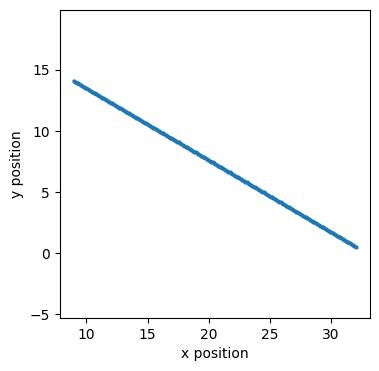

In [198]:
plt.figure(figsize=(4, 4))
plt.plot(x, y, marker="o", markersize=2)
plt.xlim(0, X_END)
plt.ylim(Y_MIN, Y_MAX)
plt.xlabel("x position")
plt.ylabel("y position")
plt.axis("equal")
plt.show()

In [199]:
raw_crossed_wall = (y_raw.min() < Y_MIN) or (y_raw.max() > Y_MAX)
raw_crossed_wall

False

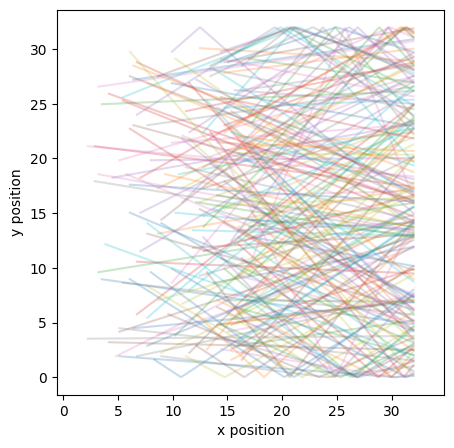

In [200]:
plt.figure(figsize=(5, 5))

for i, row in ball_df.iterrows():
    x0 = row["x0"]
    y0 = row["y0"]
    dx = row["dx"]
    dy = row["dy"]

    t_end = (X_END - x0) / dx
    t = np.linspace(0, t_end, 200)

    x = x0 + dx * t
    y_raw = y0 + dy * t
    y = reflect_y_once(y_raw, Y_MIN, Y_MAX)

    plt.plot(x, y, alpha=0.25)

plt.xlim(0, X_END)
plt.ylim(Y_MIN, Y_MAX)
plt.xlabel("x position")
plt.ylabel("y position")
plt.axis("equal")
plt.show()

In [201]:
yf_values = []

for i, row in ball_df.iterrows():
    x0 = row["x0"]
    y0 = row["y0"]
    dx = row["dx"]
    dy = row["dy"]

    t_end = (X_END - x0) / dx
    y_raw_end = y0 + dy * t_end
    yf = reflect_y_once([y_raw_end], Y_MIN, Y_MAX)[0]

    yf_values.append(yf)

ball_df["yf_reconstructed"] = yf_values

from matplotlib import cm
from matplotlib.colors import Normalize

norm = Normalize(
    vmin=ball_df["yf_reconstructed"].min(),
    vmax=ball_df["yf_reconstructed"].max()
)

cmap = cm.viridis

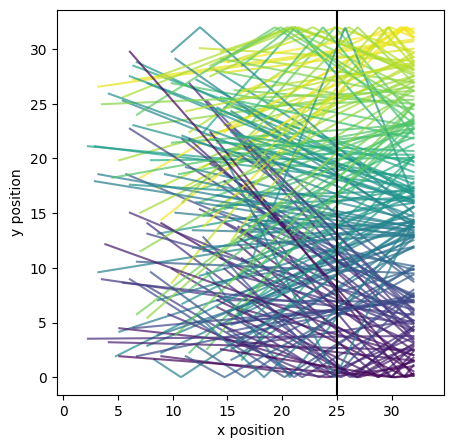

In [202]:
plt.figure(figsize=(5, 5))

for i, row in ball_df.iterrows():
    x0 = row["x0"]
    y0 = row["y0"]
    dx = row["dx"]
    dy = row["dy"]
    yf = row["yf_reconstructed"]

    t_end = (X_END - x0) / dx
    t = np.linspace(0, t_end, 200)

    x = x0 + dx * t
    y_raw = y0 + dy * t
    y = reflect_y_once(y_raw, Y_MIN, Y_MAX)

    plt.plot(x, y, color=cmap(norm(yf)), alpha=0.7)

plt.xlim(0, X_END)
plt.ylim(Y_MIN, Y_MAX)
plt.xlabel("x position")
plt.ylabel("y position")
plt.axis("equal")
plt.axvline(x=25, ymin=0, ymax=30, color="black")
plt.show()

In [203]:
# for using utils

import sys
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT.name)

Project root: dmfc-pong-reconstruction


# Figure 1C

In [204]:
from src.paths import get_project_root, get_data_dir
from src.file_utils import build_file_inventory
from src.load_data import load_pickle, inspect_object

meta = load_pickle(DATA_DIR / "valid_meta_sample_full.pkl")
dmfc_50ms = load_pickle(DATA_DIR / "all_hand_dmfc_dataset_50ms.pkl")
type(meta), type(dmfc_50ms)


(pandas.core.frame.DataFrame, dict)

In [205]:
meta.keys(), dmfc_50ms

(Index(['b0', 'heading0', 'img_h', 'img_w', 'm0', 'n_bounce', 'pad', 'speed0',
        'x0', 'y0', 'meta_index', 'n_bounce_correct', 't_f', 't_occ',
        'y_occ_hum', 'y_f_hum', 'x_occ_hum', 'x_f_hum', 'x0_mwk', 'y0_mwk',
        'dx', 'dy', 'y_occ_hum_mwk', 'y_f_hum_mwk', 'x_occ_hum_mwk',
        'x_f_hum_mwk', 'dx_hum', 'dy_hum', 'x_i_hum_mwk', 'y_i_hum_mwk',
        'y_occ_rnn', 'y_f_rnn', 'x_occ_rnn', 'x_f_rnn', 'y_occ_rnn_mwk',
        'y_f_rnn_mwk', 'x_occ_rnn_mwk', 'x_f_rnn_mwk', 'dx_rnn', 'dy_rnn',
        'x_i_rnn_mwk', 'y_i_rnn_mwk'],
       dtype='object'),
 {'trial_meta':         py_meta_index  occ_alpha  trials_from_meta  ball_offset_x  \
  0            251629.0       0.90               1.0           -1.8   
  1            464785.0       1.00               1.0            0.8   
  2             45731.0       0.90               1.0           -6.6   
  3            158705.0       1.00               1.0           -3.8   
  4             55062.0       1.00               1.0 

In [206]:
dmfc_50ms.keys()

dict_keys(['trial_meta', 'neural_meta', 'neural_responses', 'neural_responses_sh1', 'neural_responses_sh2', 'behavioral_responses', 'masks', 'ntr_vis', 'ntr_occ', 'meta', 'neural_idx_global', 'conds_ch_dict', 'reliable_neural_idx', 'neural_responses_reliable', 'neural_responses_reliable_sh1', 'neural_responses_reliable_sh2', 'neural_responses_reliable_FactorAnalysis_10', 'neural_responses_reliable_FactorAnalysis_10_sh1', 'neural_responses_reliable_FactorAnalysis_10_sh2', 'neural_responses_reliable_FactorAnalysis_20', 'neural_responses_reliable_FactorAnalysis_20_sh1', 'neural_responses_reliable_FactorAnalysis_20_sh2', 'neural_responses_reliable_FactorAnalysis_50', 'neural_responses_reliable_FactorAnalysis_50_sh1', 'neural_responses_reliable_FactorAnalysis_50_sh2'])

In [207]:
dmfc_50ms["meta"].shape, dmfc_50ms["meta"].head(), dmfc_50ms["meta"].columns

((79, 88),
                occ_alpha  trials_from_meta  ball_offset_x  ball_offset_y  \
 py_meta_index                                                              
 29337           0.970913               1.0           -7.0           -8.8   
 55062           0.972549               1.0           -6.2           -4.4   
 58244           0.971326               1.0           -6.2            4.2   
 59920           0.972288               1.0           -6.2            8.6   
 68220           0.970129               1.0           -5.8           -6.4   
 
                ball_heading  ball_speed   success   failure    ignore  \
 py_meta_index                                                           
 29337             26.577181        7.50  0.740761  0.158455  0.100784   
 55062            -32.375839        7.50  0.655709  0.304498  0.039792   
 58244            -32.375839        7.50  0.888519  0.088741  0.022740   
 59920            -48.805369       11.25  0.534084  0.436870  0.029046   
 682

all_hand_dmfc_dataset_50ms.pkl의 meta로
Figure 2B 를 그렸다는 것을 알 수 있음 (79개의 sample이 있고 논문이랑 일치함)

In [208]:
behavior = dmfc_50ms["behavioral_responses"]
if type(behavior)==dict:
    print(behavior.keys())

dict_keys(['occ', 'vis'])


In [209]:
bh_occ, bh_vis = behavior['occ'], behavior['vis']

type(bh_vis), type(bh_occ)

(dict, dict)

In [210]:
keywords = ["eye", "hand", "paddle", "joystick", "ball", "target", "occ", "time"]
for dct in [bh_occ, bh_vis]:
    for kw in keywords:
        matches = [k for k in dct.keys() if kw in str(k).lower()]
        print(kw, matches)
    print()

eye ['eye_v', 'eye_h', 'eye_dv', 'eye_dh', 'eye_dtheta', 'eye_dspeed', 'eye_dx_postmean', 'eye_dy_postmean', 'eye_dtheta_postmean', 'eye_dspeed_postmean']
hand ['hand_dx_postmean', 'hand_dy_postmean', 'hand_dtheta_postmean', 'hand_dspeed_postmean']
paddle ['paddle_pos_y']
joystick []
ball ['ball_pos_x', 'ball_pos_y', 'ball_pos_x_TRUE', 'ball_pos_y_TRUE', 'ball_pos_dx', 'ball_pos_dy', 'ball_pos_dspeed', 'ball_pos_dtheta', 'ball_pos_dx_TRUE', 'ball_pos_dy_TRUE', 'ball_pos_dspeed_TRUE', 'ball_pos_dtheta_TRUE', 'ball_pos_y_rel', 'ball_final_y', 'ball_initial_y', 'ball_occ_start_y', 'ball_pos_ego_x', 'ball_pos_ego_y', 'ball_pos_ego_x_TRUE', 'ball_pos_ego_y_TRUE']
target ['target_y', 'target_y_relative']
occ ['t_from_occ', 'ball_occ_start_y']
time []

eye ['eye_v', 'eye_h', 'eye_dv', 'eye_dh', 'eye_dtheta', 'eye_dspeed']
hand []
paddle ['paddle_pos_y']
joystick []
ball ['ball_pos_x', 'ball_pos_y', 'ball_pos_x_TRUE', 'ball_pos_y_TRUE']
target []
occ []
time []



In [211]:
for name, dct in [("vis", bh_vis), ("occ", bh_occ)]:
    print("====", name, "====")
    for key, value in dct.items():
        print(key, type(value), getattr(value, "shape", None))

==== vis ====
ball_pos_x <class 'numpy.ndarray'> (79, 100)
ball_pos_y <class 'numpy.ndarray'> (79, 100)
paddle_pos_y <class 'numpy.ndarray'> (79, 100)
joy <class 'numpy.ndarray'> (79, 100)
eye_v <class 'numpy.ndarray'> (79, 100)
eye_h <class 'numpy.ndarray'> (79, 100)
eye_dv <class 'numpy.ndarray'> (79, 100)
eye_dh <class 'numpy.ndarray'> (79, 100)
eye_dtheta <class 'numpy.ndarray'> (79, 100)
eye_dspeed <class 'numpy.ndarray'> (79, 100)
ball_pos_x_TRUE <class 'numpy.ndarray'> (79, 100)
ball_pos_y_TRUE <class 'numpy.ndarray'> (79, 100)
==== occ ====
ball_pos_x <class 'numpy.ndarray'> (79, 100)
ball_pos_y <class 'numpy.ndarray'> (79, 100)
paddle_pos_y <class 'numpy.ndarray'> (79, 100)
joy <class 'numpy.ndarray'> (79, 100)
eye_v <class 'numpy.ndarray'> (79, 100)
eye_h <class 'numpy.ndarray'> (79, 100)
eye_dv <class 'numpy.ndarray'> (79, 100)
eye_dh <class 'numpy.ndarray'> (79, 100)
eye_dtheta <class 'numpy.ndarray'> (79, 100)
eye_dspeed <class 'numpy.ndarray'> (79, 100)
ball_pos_x_TRUE <c

In [212]:
ball_x = bh_occ["ball_pos_x_TRUE"]
ball_y = bh_occ["ball_pos_y_TRUE"]

eye_x = bh_occ["eye_h"]
eye_y = bh_occ["eye_v"]

paddle_y = bh_occ["paddle_pos_y"]
target_y = bh_occ["target_y"]

t = bh_occ["t_from_occ"]

for name, arr in [
    ("ball_x", ball_x),
    ("ball_y", ball_y),
    ("eye_x", eye_x),
    ("eye_y", eye_y),
    ("paddle_y", paddle_y),
    ("target_y", target_y),
    ("t", t),
]:
    print(name, arr.shape)

ball_x (79, 100)
ball_y (79, 100)
eye_x (79, 100)
eye_y (79, 100)
paddle_y (79, 100)
target_y (79, 100)
t (79, 100)


In [213]:
eye_ball_error = ((eye_x - ball_x) ** 2 + (eye_y - ball_y) ** 2) ** 0.5
paddle_error = abs(paddle_y-target_y)

eye_ball_error.shape, paddle_error.shape

((79, 100), (79, 100))

In [214]:
import numpy as np

eye_mean = np.nanmean(eye_ball_error, axis=0)
eye_sem = np.nanstd(eye_ball_error, axis=0) / np.sqrt(eye_ball_error.shape[0])

paddle_mean = np.nanmean(paddle_error, axis=0)
paddle_sem = np.nanstd(paddle_error, axis=0) / np.sqrt(paddle_error.shape[0])

time = t[0]

C:\Users\ksbong\AppData\Local\Temp\ipykernel_36868\3485986882.py:3: RuntimeWarning: Mean of empty slice
  eye_mean = np.nanmean(eye_ball_error, axis=0)
c:\Users\ksbong\Documents\GitHub\dmfc-pong-reconstruction\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\ksbong\AppData\Local\Temp\ipykernel_36868\3485986882.py:6: RuntimeWarning: Mean of empty slice
  paddle_mean = np.nanmean(paddle_error, axis=0)


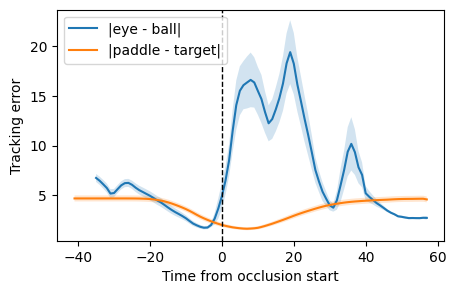

In [215]:
plt.figure(figsize=(5, 3))

plt.plot(time, eye_mean, label="|eye - ball|")
plt.fill_between(time, eye_mean - eye_sem, eye_mean + eye_sem, alpha=0.2)

plt.plot(time, paddle_mean, label="|paddle - target|")
plt.fill_between(time, paddle_mean - paddle_sem, paddle_mean + paddle_sem, alpha=0.2)

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Time from occlusion start")
plt.ylabel("Tracking error")
plt.legend()
plt.show()

In [216]:
np.nanmin(bh_occ["t_from_occ"]), np.nanmax(bh_occ["t_from_occ"])

(-42.0, 80.0)

In [217]:
np.nanmax(np.abs(bh_occ["t_from_occ"] - bh_occ["t_from_occ"][0]))

22.0

In [218]:
np.unique(bh_occ["t_from_occ"])[:20]

array([-42., -41., -40., -39., -38., -37., -36., -35., -34., -33., -32.,
       -31., -30., -29., -28., -27., -26., -25., -24., -23.])

In [219]:
unique_t = np.unique(bh_occ["t_from_occ"][~np.isnan(bh_occ["t_from_occ"])])
np.unique(np.diff(unique_t))[:20]

array([1.])

In [220]:
import numpy as np

for name, arr in [
    ("ball_x", bh_occ["ball_pos_x"]),
    ("ball_y", bh_occ["ball_pos_y"]),
    ("ball_x_TRUE", bh_occ["ball_pos_x_TRUE"]),
    ("ball_y_TRUE", bh_occ["ball_pos_y_TRUE"]),
    ("eye_h", bh_occ["eye_h"]),
    ("eye_v", bh_occ["eye_v"]),
    ("paddle_y", bh_occ["paddle_pos_y"]),
    ("target_y", bh_occ["target_y"]),
]:
    print(
        name,
        "min:", np.nanmin(arr),
        "max:", np.nanmax(arr),
        "mean:", np.nanmean(arr),
    )

ball_x min: -6.720699508298196 max: 10.086013098126308 mean: 3.5236361863111476
ball_y min: -9.840250498313049 max: 9.811985301960847 mean: -0.6954791915826115
ball_x_TRUE min: -6.7208382598862615 max: 10.507154243867262 mean: 3.641897967634764
ball_y_TRUE min: -9.804424233779589 max: 9.811976019314173 mean: -0.697945999867458
eye_h min: -82.48767294284035 max: 9.237976296686304 mean: -0.2763843009325654
eye_v min: -13.039686435852405 max: 97.35195114921727 mean: -0.07105729677522375
paddle_y min: -7.786950788000873 max: 7.415514203146007 mean: -0.13220234687641605
target_y min: -9.840250498313049 max: 8.90111219156703 mean: -0.5044307884042296


In [221]:
ball_x = bh_occ["ball_pos_x"]
ball_y = bh_occ["ball_pos_y"]

eye_x = bh_occ["eye_h"]
eye_y = bh_occ["eye_v"]

paddle_y = bh_occ["paddle_pos_y"]
target_y = bh_occ["target_y"]
t_bin = bh_occ["t_from_occ"]

eye_ball_error = np.sqrt((eye_x - ball_x) ** 2 + (eye_y - ball_y) ** 2)
paddle_error = np.abs(paddle_y - target_y)

In [222]:
valid_time = bh_occ["t_from_end"] <= 0

eye_ball_error = np.where(valid_time, eye_ball_error, np.nan)
paddle_error = np.where(valid_time, paddle_error, np.nan)

window = (t_bin >= -40) & (t_bin <= 35)
eye_ball_error = np.where(window, eye_ball_error, np.nan)
paddle_error = np.where(window, paddle_error, np.nan)

err_df = pd.DataFrame({
    "time_bin": t_bin.ravel(),
    "eye_ball_error": eye_ball_error.ravel(),
    "paddle_error": paddle_error.ravel(),
})

err_df = err_df.dropna()

summary = (
    err_df
    .groupby("time_bin")
    .agg(
        eye_mean=("eye_ball_error", "mean"),
        eye_std=("eye_ball_error", "std"),
        eye_n=("eye_ball_error", "count"),
        paddle_mean=("paddle_error", "mean"),
        paddle_std=("paddle_error", "std"),
        paddle_n=("paddle_error", "count"),
    )
    .reset_index()
)

summary["eye_sem"] = summary["eye_std"] / np.sqrt(summary["eye_n"])
summary["paddle_sem"] = summary["paddle_std"] / np.sqrt(summary["paddle_n"])
summary["time_ms"] = summary["time_bin"] * 50

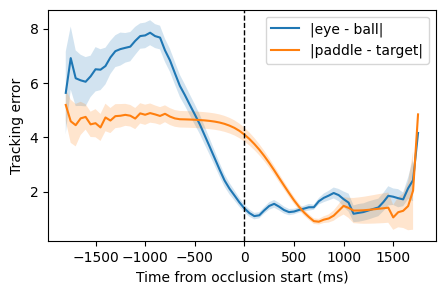

In [223]:
plt.figure(figsize=(5, 3))

plt.plot(summary["time_ms"], summary["eye_mean"], label="|eye - ball|")
plt.fill_between(
    summary["time_ms"],
    summary["eye_mean"] - summary["eye_sem"],
    summary["eye_mean"] + summary["eye_sem"],
    alpha=0.2,
)

plt.plot(summary["time_ms"], summary["paddle_mean"], label="|paddle - target|")
plt.fill_between(
    summary["time_ms"],
    summary["paddle_mean"] - summary["paddle_sem"],
    summary["paddle_mean"] + summary["paddle_sem"],
    alpha=0.2,
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Time from occlusion start (ms)")
plt.ylabel("Tracking error")
plt.legend()
plt.show()

The three example panels below use temporary dataset condition indices `[0, 20, 40]`.
They are not yet confirmed to be the exact three example conditions shown in the published Figure 1C.

In [224]:
import pandas as pd

source_path = DATA_DIR / "Source_Data.xlsx"

xls = pd.ExcelFile(source_path)
[s for s in xls.sheet_names if "1" in s.lower()]

['Figure 1c', 'Figure S1A', 'Figure S1B']

In [225]:
fig1c_src = pd.read_excel(source_path, sheet_name="Figure 1c", header=None)
fig1c_src.shape

(74, 26)

In [226]:
nonempty = []

for r in range(fig1c_src.shape[0]):
    for c in range(fig1c_src.shape[1]):
        value = fig1c_src.iat[r, c]
        if pd.notna(value):
            nonempty.append((r, c, value))

nonempty[:80]

[(2, 0, 'Figure 1c'),
 (4, 0, 'condition1'),
 (4, 7, 'condition3'),
 (4, 14, 'condition2'),
 (4, 21, 'tracking error'),
 (5, 0, 'eye x'),
 (5, 1, 'eye y'),
 (5, 2, 'ball x'),
 (5, 3, 'ball y'),
 (5, 4, 'paddle x'),
 (5, 5, 'paddle y'),
 (5, 7, 'eye x'),
 (5, 8, 'eye y'),
 (5, 9, 'ball x'),
 (5, 10, 'ball y'),
 (5, 11, 'paddle x'),
 (5, 12, 'paddle y'),
 (5, 14, 'eye x'),
 (5, 15, 'eye y'),
 (5, 16, 'ball x'),
 (5, 17, 'ball y'),
 (5, 18, 'paddle x'),
 (5, 19, 'paddle y'),
 (5, 21, 'time'),
 (5, 22, 'mean(eye-ball)'),
 (5, 23, 'SEM(eye-ball)'),
 (5, 24, 'mean(paddle-target)'),
 (5, 25, 'SEM(paddle-target)'),
 (6, 0, '    1.4001   -4.8202'),
 (6, 2, '   -2.5791   -8.3795'),
 (6, 4, '   -2.5791   -0.0013'),
 (6, 7, 0.8481),
 (6, 8, -5.1666),
 (6, 9, 0.8016),
 (6, 10, 5.2384),
 (6, 11, 0.8016),
 (6, 12, -0.0005),
 (6, 14, 0.8204),
 (6, 15, -5.2219),
 (6, 16, -0.6597),
 (6, 17, 2.3211),
 (6, 18, -0.6597),
 (6, 19, 0),
 (6, 21, -1800),
 (6, 22, 5.852),
 (6, 23, 1.6744),
 (6, 24, 5.1919),
 (6

In [227]:
for r, c, value in nonempty:
    if "condition" in str(value).lower():
        print(r, c, value)

4 0 condition1
4 7 condition3
4 14 condition2


In [228]:
for r, c, value in nonempty:
    if "ball" in str(value).lower():
        print(r, c, value)

5 2 ball x
5 3 ball y
5 9 ball x
5 10 ball y
5 16 ball x
5 17 ball y
5 22 mean(eye-ball)
5 23 SEM(eye-ball)


In [229]:
cond1_block = fig1c_src.iloc[:, 0:6]
cond2_block = fig1c_src.iloc[:, 7:13]
cond3_block = fig1c_src.iloc[:, 14:20]

In [230]:
def find_label_position(block, label):
    label = label.lower().strip()

    for r in range(block.shape[0]):
        for c in range(block.shape[1]):
            value = block.iat[r, c]
            if pd.isna(value):
                continue

            if str(value).lower().strip() == label:
                return r, c

    return None


def extract_xy_from_block(block, label_x="ball x", label_y="ball y"):
    x_pos = find_label_position(block, label_x)
    y_pos = find_label_position(block, label_y)

    if x_pos is None:
        raise ValueError(f"Could not find label: {label_x}")

    header_row, x_col = x_pos
    raw_x = block.iloc[header_row + 1:, x_col].dropna()

    parts = (
        raw_x.astype(str)
        .str.strip()
        .str.split(r"\s+", expand=True)
    )
    if parts.shape[1] >= 2:
        xy = parts.iloc[:, :2].apply(pd.to_numeric, errors="coerce")
        xy.columns = ["x", "y"]
        xy = xy.dropna().reset_index(drop=True)

        if len(xy) > 0:
            print(f"{label_x}: parsed as packed x-y format")
            return xy

    if y_pos is not None:
        _, y_col = y_pos
    else:
        y_col = x_col + 1

    x = pd.to_numeric(block.iloc[header_row + 1:, x_col], errors="coerce")
    y = pd.to_numeric(block.iloc[header_row + 1:, y_col], errors="coerce")

    xy = pd.DataFrame({
        "x": x,
        "y": y,
    }).dropna().reset_index(drop=True)

    if len(xy) > 0:
        print(f"{label_x}: parsed as separate x/y columns")
        return xy

    raise ValueError(f"Could not extract x/y values for {label_x}.")

In [231]:
src_cond1 = extract_xy_from_block(cond1_block, label_x="ball x", label_y="ball y")
src_cond2 = extract_xy_from_block(cond2_block, label_x="ball x", label_y="ball y")
src_cond3 = extract_xy_from_block(cond3_block, label_x="ball x", label_y="ball y")

src_cond1.shape, src_cond2.shape, src_cond3.shape

ball x: parsed as packed x-y format
ball x: parsed as separate x/y columns
ball x: parsed as separate x/y columns


((49, 2), (40, 2), (65, 2))

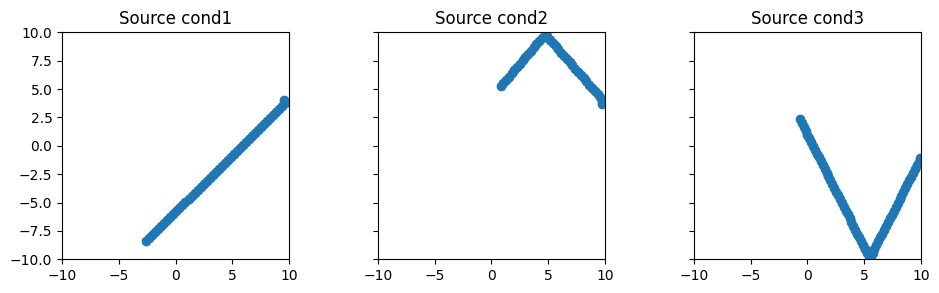

In [232]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

for ax, src_ball, title in zip(
    axes,
    [src_cond1, src_cond2, src_cond3],
    ["Source cond1", "Source cond2", "Source cond3"],
):
    ax.plot(src_ball["x"], src_ball["y"], "o-")
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect("equal")
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [233]:
meta79 = dmfc_50ms["meta"].reset_index(drop=True)

print(meta79.shape)
print(meta79.columns.tolist())

(79, 88)
['occ_alpha', 'trials_from_meta', 'ball_offset_x', 'ball_offset_y', 'ball_heading', 'ball_speed', 'success', 'failure', 'ignore', 'joystick_output', 'dataset_idx', 'experiment_idx', 'controller_on', 'py_x0', 'py_y0', 'py_heading0', 'py_speed', 'py_n_bounce', 'py_pad_size_mwk', 'py_pad_location_mwk', 'py_portal1_x', 'py_portal1_y', 'py_portal1_size_x', 'py_portal1_size_y', 'py_portal1_theta', 'py_portal2_x', 'py_portal2_y', 'py_portal2_size_x', 'py_portal2_size_y', 'py_portal2_theta', 'ball_pos_x_from_mwk', 'ball_pos_y_from_mwk', 'paddle_pos_x_from_mwk', 'paddle_pos_y_from_mwk', 'photodiode_rectangle_pos_x_from_mwk', 'photodiode_rectangle_pos_y_from_mwk', 'session_date', 'b0', 'heading0', 'img_h', 'img_w', 'm0', 'n_bounce', 'pad', 'speed0', 'x0', 'y0', 'meta_index', 'n_bounce_correct', 'yf', 'x0_mworks', 'y0_mworks', 'yf_mworks', 'n_teleport', 'portal1_size_x', 'portal1_size_y', 'portal1_theta', 'portal1_x', 'portal1_y', 'portal2_size_x', 'portal2_size_y', 'portal2_theta', 'por

In [234]:
# SourceData trajectory -> dmfc_50ms meta trajectory 직접 매칭

meta79 = dmfc_50ms["meta"].reset_index(drop=True)

source_conditions = [src_cond1, src_cond2, src_cond3]


def reflect_y(y, y_min, y_max):
    y = np.asarray(y, dtype=float).copy()
    y = np.where(y < y_min, 2 * y_min - y, y)
    y = np.where(y > y_max, 2 * y_max - y, y)
    return y


def predict_y_from_meta_at_source_x(row, src_x):
    """
    SourceData의 x 좌표를 기준으로,
    dmfc meta의 x0/y0/dx/dy로 y trajectory를 예측한다.
    가능한 좌표계 후보를 자동으로 시도한다.
    """

    candidates = []

    # 1) mwk / degree 좌표계 후보
    if all(c in row.index for c in ["x0_mwk", "y0_mwk", "dx_hum", "dy_hum"]):
        candidates.append({
            "name": "mwk_hum",
            "x0": row["x0_mwk"],
            "y0": row["y0_mwk"],
            "dx": row["dx_hum"],
            "dy": row["dy_hum"],
            "x_input": src_x,
            "y_min": -10,
            "y_max": 10,
            "to_plot_x": src_x,
            "to_plot_y": lambda y: y,
        })

    if all(c in row.index for c in ["x_i_hum_mwk", "y_i_hum_mwk", "dx_hum", "dy_hum"]):
        candidates.append({
            "name": "mwk_i_hum",
            "x0": row["x_i_hum_mwk"],
            "y0": row["y_i_hum_mwk"],
            "dx": row["dx_hum"],
            "dy": row["dy_hum"],
            "x_input": src_x,
            "y_min": -10,
            "y_max": 10,
            "to_plot_x": src_x,
            "to_plot_y": lambda y: y,
        })

    # 2) internal 0~32 좌표계 후보
    # SourceData는 -10~10 degree라서 source x를 internal coordinate로 바꿔 비교
    if all(c in row.index for c in ["x0", "y0", "dx", "dy"]):
        scale = 20 / 32
        src_x_internal = src_x / scale + 16

        candidates.append({
            "name": "internal_to_deg",
            "x0": row["x0"],
            "y0": row["y0"],
            "dx": row["dx"],
            "dy": row["dy"],
            "x_input": src_x_internal,
            "y_min": 0,
            "y_max": 32,
            "to_plot_x": src_x,
            "to_plot_y": lambda y: (y - 16) * scale,
        })

    if len(candidates) == 0:
        raise ValueError("No usable trajectory columns found in meta79.")

    outputs = []

    for cand in candidates:
        x0 = float(cand["x0"])
        y0 = float(cand["y0"])
        dx = float(cand["dx"])
        dy = float(cand["dy"])

        if not np.isfinite(dx) or abs(dx) < 1e-12:
            continue

        # x 기준으로 y 예측
        y_raw = y0 + (dy / dx) * (cand["x_input"] - x0)
        y_ref = reflect_y(y_raw, cand["y_min"], cand["y_max"])
        y_plot = cand["to_plot_y"](y_ref)

        outputs.append((cand["name"], cand["to_plot_x"], y_plot))

    return outputs


def match_one_source_condition(src_ball, meta_df):
    src = src_ball.dropna().reset_index(drop=True)
    src_x = src["x"].to_numpy(dtype=float)
    src_y = src["y"].to_numpy(dtype=float)

    scores = []

    for cond, row in meta_df.iterrows():
        try:
            preds = predict_y_from_meta_at_source_x(row, src_x)
        except Exception:
            continue

        for pred_name, pred_x, pred_y in preds:
            valid = np.isfinite(pred_y) & np.isfinite(src_y)

            if valid.sum() < 3:
                continue

            mse = np.mean((src_y[valid] - pred_y[valid]) ** 2)

            scores.append({
                "cond": cond,
                "trajectory_source": pred_name,
                "score": mse,
            })

    return pd.DataFrame(scores).sort_values("score").reset_index(drop=True)


match_results = []

for j, src_ball in enumerate(source_conditions, start=1):
    result = match_one_source_condition(src_ball, meta79)

    print(f"Condition #{j} top 10")
    display(result.head(10))

    best = result.iloc[0]
    match_results.append(best)

matches_df = pd.DataFrame(match_results)
matches_df.index = ["Condition #1", "Condition #2", "Condition #3"]

real_conditions = matches_df["cond"].astype(int).tolist()

print("real_conditions:", real_conditions)
matches_df

Condition #1 top 10


,cond,trajectory_source,score
0,24,internal_to_deg,0.002108
1,37,internal_to_deg,0.477415
2,71,internal_to_deg,0.702485
3,57,internal_to_deg,1.082859
4,58,internal_to_deg,1.323613
5,16,internal_to_deg,2.422486
6,19,internal_to_deg,3.367311
7,74,internal_to_deg,4.528062
8,25,internal_to_deg,4.960861
9,0,internal_to_deg,5.085977


Condition #2 top 10


,cond,trajectory_source,score
0,73,internal_to_deg,0.028156
1,78,internal_to_deg,0.829492
2,69,internal_to_deg,2.129309
3,36,internal_to_deg,2.437468
4,5,internal_to_deg,3.072470
5,47,internal_to_deg,3.089102
6,43,internal_to_deg,3.608786
7,27,internal_to_deg,3.908600
8,42,internal_to_deg,3.970304
9,20,internal_to_deg,4.291487


Condition #3 top 10


,cond,trajectory_source,score
0,51,internal_to_deg,0.007651
1,33,internal_to_deg,9.073601
2,49,internal_to_deg,9.180581
3,32,internal_to_deg,9.335312
4,64,internal_to_deg,9.652018
5,63,internal_to_deg,10.259381
6,76,internal_to_deg,11.734203
7,50,internal_to_deg,11.990562
8,2,internal_to_deg,12.575992
9,26,internal_to_deg,12.739215


real_conditions: [24, 73, 51]


,cond,trajectory_source,score
Condition #1,24,internal_to_deg,0.002108
Condition #2,73,internal_to_deg,0.028156
Condition #3,51,internal_to_deg,0.007651


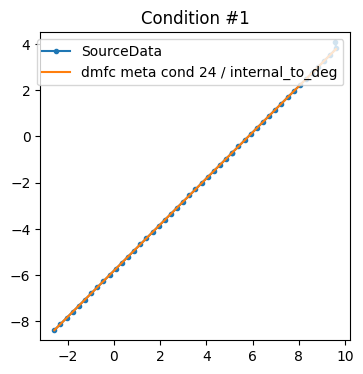

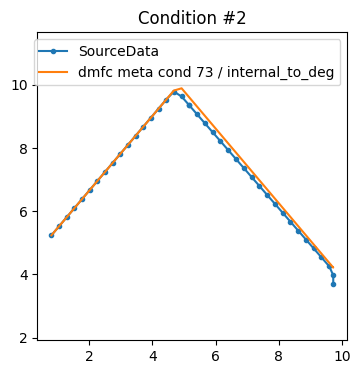

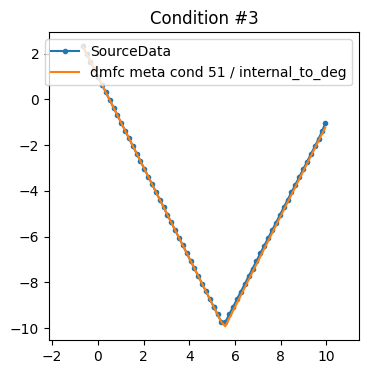

In [235]:
def plot_meta_trajectory_match(src_ball, match, title):
    cond = int(match["cond"])
    row = meta79.iloc[cond]

    src = src_ball.dropna().reset_index(drop=True)
    src_x = src["x"].to_numpy(dtype=float)
    src_y = src["y"].to_numpy(dtype=float)

    preds = predict_y_from_meta_at_source_x(row, src_x)

    # matching에서 선택된 trajectory_source만 사용
    selected_name = match["trajectory_source"]
    selected = [p for p in preds if p[0] == selected_name][0]
    _, pred_x, pred_y = selected

    plt.figure(figsize=(4, 4))
    plt.plot(src_x, src_y, "o-", markersize=3, label="SourceData")
    plt.plot(pred_x, pred_y, "-", label=f"dmfc meta cond {cond} / {selected_name}")

    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.axis("equal")
    plt.legend()
    plt.title(title)
    plt.show()


for j, src_ball in enumerate(source_conditions, start=1):
    plot_meta_trajectory_match(
        src_ball,
        matches_df.iloc[j - 1],
        f"Condition #{j}"
    )

In [236]:
def get_behavior_ball_candidate(bh, cond, use_true=False):
    if use_true:
        x = bh["ball_pos_x_TRUE"][cond]
        y = bh["ball_pos_y_TRUE"][cond]
    else:
        x = bh["ball_pos_x"][cond]
        y = bh["ball_pos_y"][cond]

    return np.asarray(x, dtype=float), np.asarray(y, dtype=float)


def match_source_ball_to_behavior_indices(src_ball, cond):
    """
    SourceData ball trajectory와 가장 잘 맞는 dmfc behavior array를 찾고,
    SourceData 각 point에 대응하는 dmfc time index를 반환한다.
    """

    src_x = src_ball["x"].to_numpy(dtype=float)
    src_y = src_ball["y"].to_numpy(dtype=float)

    candidates = []

    for bh_name, bh in [("vis", bh_vis), ("occ", bh_occ)]:
        for use_true in [False, True]:
            bx, by = get_behavior_ball_candidate(bh, cond, use_true=use_true)

            valid = np.isfinite(bx) & np.isfinite(by)
            bx_valid = bx[valid]
            by_valid = by[valid]
            original_idx = np.where(valid)[0]

            if len(bx_valid) == 0:
                continue

            matched_idx = []
            dists = []

            for sx, sy in zip(src_x, src_y):
                d2 = (bx_valid - sx) ** 2 + (by_valid - sy) ** 2
                k = int(np.nanargmin(d2))

                matched_idx.append(original_idx[k])
                dists.append(d2[k])

            candidates.append({
                "bh_name": bh_name,
                "use_true": use_true,
                "indices": np.array(matched_idx, dtype=int),
                "score": float(np.nanmean(dists)),
            })

    candidates = sorted(candidates, key=lambda d: d["score"])
    return candidates

real_conditions = [24, 73, 51]
source_conditions = [src_cond1, src_cond2, src_cond3]

index_matches = []

for j, (src_ball, cond) in enumerate(zip(source_conditions, real_conditions), start=1):
    candidates = match_source_ball_to_behavior_indices(src_ball, cond)

    print(f"Condition #{j} / dmfc idx {cond}")
    for cand in candidates[:5]:
        print(cand["bh_name"], "TRUE" if cand["use_true"] else "nonTRUE", cand["score"])

    index_matches.append(candidates[0])
    print()

Condition #1 / dmfc idx 24
occ nonTRUE 2.2835963351391319e-07
vis nonTRUE 0.0001323351903930043
vis TRUE 0.00021910892890838102
occ TRUE 0.00021910892890838102

Condition #2 / dmfc idx 73
occ nonTRUE 1.555647382341817e-08
vis nonTRUE 0.0022773695778958588
vis TRUE 0.002718269450536219
occ TRUE 0.002718269450536219

Condition #3 / dmfc idx 51
occ nonTRUE 1.0515263713407333e-06
vis TRUE 5.9304634295818804e-05
occ TRUE 5.9304634295818804e-05
vis nonTRUE 0.003803708643357928



In [237]:
from matplotlib.colors import Normalize

def draw_condition_using_matched_indices(ax, src_ball, cond, index_match, title):
    bh = bh_vis if index_match["bh_name"] == "vis" else bh_occ
    idx = index_match["indices"]

    use_true = index_match["use_true"]

    if use_true:
        ball_x = bh["ball_pos_x_TRUE"][cond][idx]
        ball_y = bh["ball_pos_y_TRUE"][cond][idx]
    else:
        ball_x = bh["ball_pos_x"][cond][idx]
        ball_y = bh["ball_pos_y"][cond][idx]

    eye_x = bh["eye_h"][cond][idx]
    eye_y = bh["eye_v"][cond][idx]
    paddle_y = bh["paddle_pos_y"][cond][idx]

    if "t_from_occ" in bh:
        time_i = bh["t_from_occ"][cond][idx]
    else:
        time_i = np.arange(len(idx))

    valid_ball = (
        np.isfinite(ball_x)
        & np.isfinite(ball_y)
        & np.isfinite(paddle_y)
    )

    valid_eye = (
        np.isfinite(eye_x)
        & np.isfinite(eye_y)
        & (eye_x >= -10)
        & (eye_x <= 10)
        & (eye_y >= -10)
        & (eye_y <= 10)
    )

    valid = valid_ball & valid_eye

    # Ball
    ax.plot(
        ball_x[valid_ball],
        ball_y[valid_ball],
        color="black",
        linewidth=2.0,
        label="Ball",
        zorder=3
    )

    cmap = plt.get_cmap("viridis")
    norm = Normalize(
        vmin=np.nanmin(time_i[valid]),
        vmax=np.nanmax(time_i[valid]),
    )
    
    eye_colors = cmap(norm(time_i[valid]))
    # Eye
    ax.scatter(
        eye_x[valid],
        eye_y[valid],
        facecolors="white",
        edgecolors=eye_colors,
        s=18,
        linewidth=0.8,
        label="Eye",
        zorder=4
    )

    # Tracking error lines
    valid_idx = np.where(valid)[0]
    for k in valid_idx[::3]:
        line_color = cmap(norm(time_i[k]))
    
        ax.plot(
            [ball_x[k], eye_x[k]],
            [ball_y[k], eye_y[k]],
            color=line_color,
            alpha=0.7,
            linewidth=2.0,
            zorder=1,
        )
        
        # Eye trajectory line: connect eye positions over time
        ax.plot(
            eye_x[valid],
            eye_y[valid],
            color="black",
            linewidth=0.8,
            alpha=0.8,
            zorder=2,
        )

    # Paddle y at corresponding ball x
    ax.plot(
        ball_x[valid_ball],
        paddle_y[valid_ball],
        color="magenta",
        linewidth=2.0,
        label="Paddle y",
        zorder=5
    )

    ax.axvline(5, 
        color="black", linestyle=":", 
        linewidth=1.2, zorder=0)

    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect("equal")
    ax.set_xlabel("x position")
    ax.set_ylabel("y position")
    ax.set_title(title)

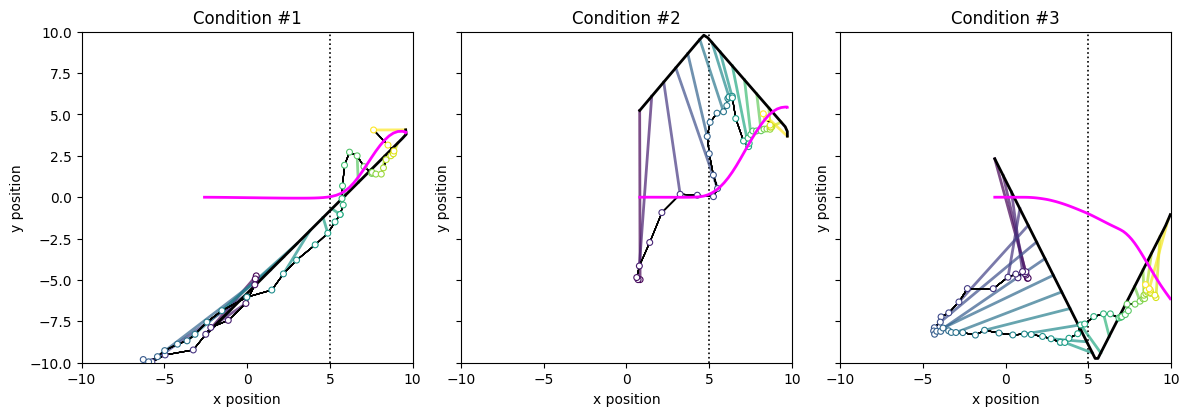

In [238]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

for j, (ax, src_ball, cond, idx_match) in enumerate(
    zip(axes, source_conditions, real_conditions, index_matches),
    start=1,
):
    draw_condition_using_matched_indices(
        ax,
        src_ball,
        cond,
        idx_match,
        f"Condition #{j}",
    )

plt.tight_layout()
plt.show()